# Hansard demo

A worked example using the bundled Hansard-style sample corpus. The sample is **synthetic** but its structure mirrors real UK parliamentary discourse:

- 193 speeches across 19 years (2005–2023)
- Four topics: immigration, Brexit, NHS, climate
- Four parties: Labour, Conservative, Liberal Democrat, SNP
- Frame shifts at real historical inflection points: immigration goes humanising → criminalising around the 2016 Brexit referendum, NHS sees austerity (2010–14) and COVID (2020–22) pressure, climate sharpens scientific → policy → crisis post-2019

For an actual research project: see `pycorpdiff.datasets.hansard` for canonical sources of real Hansard (TheyWorkForYou, parliament.uk, HuggingFace).

This notebook drives every analytical surface in the package on a single corpus — what a real research workflow looks like end-to-end.

In [1]:
import altair as alt

import pycorpdiff as pcd

# Emit charts as inline Vega-Lite JSON so they render on GitHub, in
# JupyterLab, VS Code, and nbviewer — anywhere the
# application/vnd.vegalite mime is honoured.
alt.renderers.enable('svg')

corpus = pcd.load_hansard_sample()
print(f'{len(corpus):,} speeches · {corpus.total_tokens():,} tokens')
corpus.docs.head(3)

193 speeches · 5,416 tokens


,speech_id,text,topic,frame,party,date,year
0,0,"Mr Speaker, I wish to make a statement concern...",climate,scientific,Conservative,2005-08-15,2005
1,1,I beg leave to bring to the attention of this ...,climate,scientific,Labour,2005-01-05,2005
2,2,I am pleased to speak on the matter of brexit....,brexit,emerging,Liberal Democrat,2005-04-09,2005


## 1. Cross-party frame contrast on immigration

Slice the corpus to immigration speeches, then split by the engineered frame (humanising vs criminalising). Keyness reveals the lexical fingerprints of each frame.

In [2]:
immigration = corpus.slice(topic='immigration')
h = immigration.slice(frame='humanising')
c = immigration.slice(frame='criminalising')
print(f'humanising: {len(h)} speeches · {h.total_tokens()} tokens')
print(f'criminalising: {len(c)} speeches · {c.total_tokens()} tokens')

humanising: 28 speeches · 786 tokens
criminalising: 21 speeches · 582 tokens


In [3]:
keyness = pcd.compare(h, c).keyness(min_count=3, dispersion=True)
print(keyness.summary())
keyness.table.head(10)

KeynessResult(log_likelihood, |a|=786, |b|=582, terms=119)


,term,count_a,count_b,expected_a,expected_b,g2,p_value,log_ratio,percent_diff,bayes_factor,dispersion_a,dispersion_b,dispersion_flag,p_adjusted
0,criminal,0,18,10.342105,7.657895,-30.766847,2.909666e-08,-5.642964,-100.0,129685.965757,0.000000,0.902825,True,0.000003
1,gangs,0,12,6.894737,5.105263,-20.511232,5.928237e-06,-5.077366,-100.0,768.978689,0.000000,0.800527,True,0.000353
2,family,17,0,9.767544,7.232456,18.841042,1.420767e-05,4.695773,inf,333.608666,0.844731,0.000000,True,0.000564
3,invasion,0,10,5.745614,4.254386,-17.092693,3.559901e-05,-4.825828,-100.0,139.183604,0.000000,0.762555,True,0.001059
4,worker,14,0,8.043860,5.956140,15.516153,8.180325e-05,4.424471,inf,63.277115,0.804029,0.000000,True,0.001740
5,threat,0,9,5.171053,3.828947,-15.383424,8.775475e-05,-4.681438,-100.0,59.214077,0.000000,0.740643,True,0.001740
6,border,0,8,4.596491,3.403509,-13.674154,2.174264e-04,-4.520973,-100.0,25.191954,0.000000,0.712765,True,0.003234
7,grows,0,8,4.596491,3.403509,-13.674154,2.174264e-04,-4.520973,-100.0,25.191954,0.000000,0.712991,True,0.003234
8,community,8,0,4.596491,3.403509,8.866373,2.904717e-03,3.653953,inf,2.276488,0.694073,0.000000,True,0.031692
9,daily,0,5,2.872807,2.127193,-8.546347,3.462164e-03,-3.892942,-100.0,1.939870,0.000000,0.598185,True,0.031692


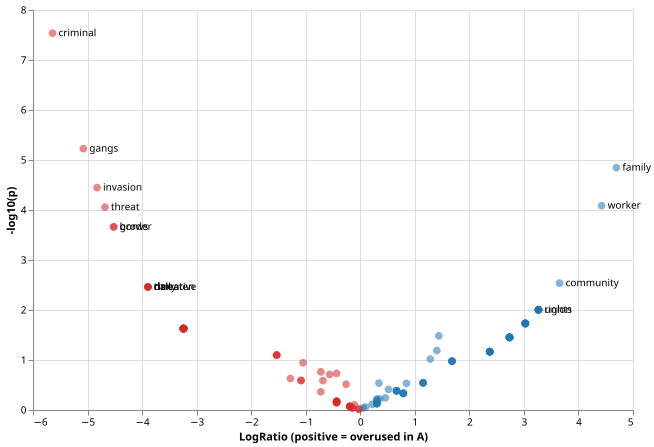

In [4]:
keyness.plot()

### Explain a top result

Real KWIC contexts from both frames for the highest-keyness term.

In [5]:
top_term = keyness.table.iloc[0]['term']
keyness.explain(top_term, n=3, window=4).table

,corpus,doc_id,position,left,keyword,right
0,"topic='immigration', frame='criminalising'",0,17,border and the immigrant,criminal,risk grows daily i
1,"topic='immigration', frame='criminalising'",1,11,consider immigration the immigrant,criminal,threat grows and the
2,"topic='immigration', frame='criminalising'",2,18,border and the immigrant,criminal,risk grows daily i


## 2. What does each frame put next to 'immigrant'?

`collocation_shift` measures the window-based co-occurrence of every collocate around a target and reports the cross-corpus difference. Strong negative shifts here mean the collocate is dominantly associated with the criminalising frame.

In [6]:
shift = pcd.compare(h, c).collocation_shift(
    'immigrant', window=4, min_count=3, measure='logDice'
)
print(shift.summary())
shift.table.head(10)

CollocationShiftResult(target='immigrant', measure=logDice, window=4, collocates=63)


,collocate,count_a,count_b,score_a,score_b,shift
0,criminal,0,18,8.678072,13.351472,-4.673400
1,family,17,0,13.296393,8.678072,4.618321
2,gangs,0,14,8.678072,13.157541,-4.479469
3,worker,14,0,13.103093,8.678072,4.425022
4,threat,0,12,8.678072,13.029146,-4.351074
5,grows,0,11,8.678072,12.938599,-4.260528
6,hope,10,0,12.900464,8.678072,4.222392
7,thrived,10,0,12.900464,8.678072,4.222392
8,border,0,10,8.678072,12.807355,-4.129283
9,invasion,0,10,8.678072,12.748461,-4.070389


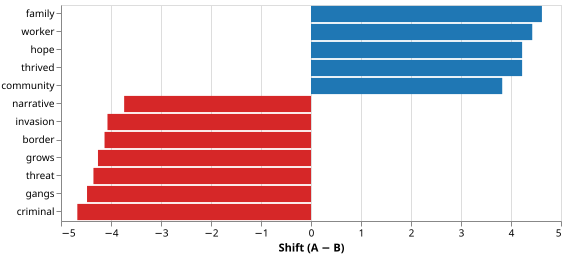

In [7]:
shift.plot(n=12)

## 3. Temporal trajectory of the criminalising frame

How does 'criminal' track over time in immigration speeches?

In [8]:
trajectory = pcd.track(immigration, ['criminal', 'worker', 'family']).over_time(
    freq='Y', time_col='date'
)
trajectory.table.head(10)

,period,term,count,total,relfreq,ci_lower,ci_upper
0,2005,criminal,0,55,0.0,0.000000e+00,0.065285
1,2006,criminal,0,58,0.0,0.000000e+00,0.062118
2,2007,criminal,0,83,0.0,3.469447e-18,0.044235
3,2008,criminal,0,28,0.0,1.387779e-17,0.120643
4,2009,criminal,0,27,0.0,0.000000e+00,0.124555
5,2010,criminal,0,27,0.0,0.000000e+00,0.124555
6,2011,criminal,0,83,0.0,3.469447e-18,0.044235
7,2012,criminal,0,55,0.0,0.000000e+00,0.065285
8,2013,criminal,0,27,0.0,0.000000e+00,0.124555
9,2014,criminal,0,169,0.0,0.000000e+00,0.022225


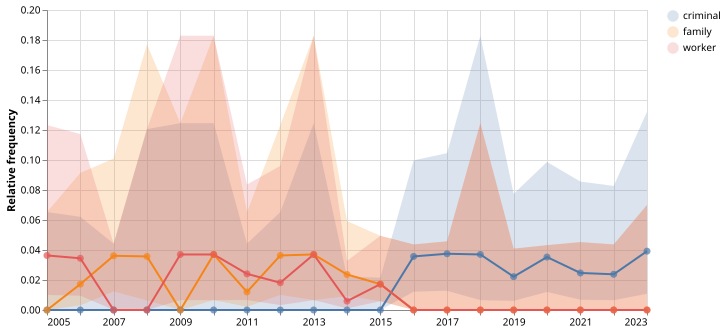

In [9]:
trajectory.plot()

### Changepoint detection

Where does the discourse around 'criminal' break? PELT should locate the engineered 2016 referendum shift.

In [10]:
trajectory.changepoints(target='criminal')

,period,index,method
0,2015,10,pelt


### Interrupted time series at the 2016 referendum

Quantify the post-event level change with a segmented regression.

> **Caveat on the synthetic demo.** The bundled Hansard-style sample is deterministic — the engineered relative frequencies for `"criminal"` in the pre-event window have zero variance, so the OLS standard errors below are at floating-point precision and the *p*-values are astronomically small. On real data with realistic noise these numbers will be normal-looking. Treat the ITS output here as a syntactic demonstration of the API, not a statistical worked example.

In [11]:
trajectory.interrupted_time_series(event_date='2016', target='criminal')

,term,coef,std_err,t,p_value,ci_lower,ci_upper
0,intercept,-4.203235e-18,0.002609,-1.610897e-15,1.000000e+00,-0.005561,0.005561
1,time,-7.487918e-19,0.000441,-1.697771e-15,1.000000e+00,-0.000940,0.000940
2,level_change,3.476502e-02,0.004227,8.225463e+00,6.104811e-07,0.025756,0.043774
3,slope_change,-8.084252e-04,0.000839,-9.635201e-01,3.505638e-01,-0.002597,0.000980


## 4. Cross-topic comparison

How does climate discourse differ from NHS discourse? Different topical fields entirely — keyness should surface each topic's signature vocabulary.

In [12]:
climate_v_nhs = pcd.compare(
    corpus.slice(topic='climate'),
    corpus.slice(topic='nhs'),
).keyness(min_count=3)
climate_v_nhs.table.head(10)

,term,count_a,count_b,expected_a,expected_b,g2,p_value,log_ratio,percent_diff,bayes_factor,p_adjusted
0,climate,122,0,61.328546,60.671454,167.817255,2.217774e-38,7.921097,inf,5.231683e+34,4.014171e-36
1,nhs,0,102,51.274686,50.725314,-142.503738,7.546361e-33,-7.695021,-100.0,1.666790e+29,6.829457e-31
2,policy,16,0,8.043088,7.956912,22.008820,2.714004e-06,5.028853,inf,1.139573e+03,1.637449e-04
3,care,0,13,6.535009,6.464991,-18.162241,2.028612e-05,-4.770428,-100.0,1.665206e+02,9.179471e-04
4,targets,12,0,6.032316,5.967684,16.506615,4.848063e-05,4.628315,inf,7.277017e+01,1.462499e-03
5,is,12,0,6.032316,5.967684,16.506615,4.848063e-05,4.628315,inf,7.277017e+01,1.462499e-03
6,funding,0,11,5.529623,5.470377,-15.368050,8.847167e-05,-4.539103,-100.0,4.118292e+01,2.269270e-03
7,emissions,11,0,5.529623,5.470377,15.131064,1.002992e-04,4.508021,inf,3.658105e+01,2.269270e-03
8,underfunding,0,10,5.026930,4.973070,-13.970955,1.856567e-04,-4.407858,-100.0,2.048055e+01,2.355363e-03
9,reduction,10,0,5.026930,4.973070,13.755513,2.082089e-04,4.376777,inf,1.838904e+01,2.355363e-03


## 5. Cross-party comparison

Slice the same topic by party — Labour vs Conservative speeches on the NHS.

In [13]:
nhs = corpus.slice(topic='nhs')
lab_v_con = pcd.compare(
    nhs.slice(party='Labour'),
    nhs.slice(party='Conservative'),
).keyness(min_count=2)
print(lab_v_con.summary())
lab_v_con.table.head(8)

KeynessResult(log_likelihood, |a|=345, |b|=340, terms=115)


,term,count_a,count_b,expected_a,expected_b,g2,p_value,log_ratio,percent_diff,bayes_factor,p_adjusted
0,commend,4,0,2.014599,1.985401,5.486995,0.019158,3.148863,inf,0.593801,0.543034
1,motion,4,0,2.014599,1.985401,5.486995,0.019158,3.148863,inf,0.593801,0.543034
2,move,0,3,1.510949,1.489051,-4.202839,0.040356,-2.828417,-100.0,0.312457,0.543034
3,workforce,3,0,1.510949,1.489051,4.115247,0.042498,2.786293,inf,0.299067,0.543034
4,supported,3,0,1.510949,1.489051,4.115247,0.042498,2.786293,inf,0.299067,0.543034
5,training,3,0,1.510949,1.489051,4.115247,0.042498,2.786293,inf,0.299067,0.543034
6,programmes,3,0,1.510949,1.489051,4.115247,0.042498,2.786293,inf,0.299067,0.543034
7,proper,3,0,1.510949,1.489051,4.115247,0.042498,2.786293,inf,0.299067,0.543034


## 6. Before/after the 2016 referendum

The full corpus split chronologically — what changed across the whole parliamentary discourse?

In [14]:
ba = pcd.compare.before_after(
    corpus, event_date='2016-06-23', time_col='date'
).keyness(min_count=5)
ba.table.head(10)

,term,count_a,count_b,expected_a,expected_b,g2,p_value,log_ratio,percent_diff,bayes_factor,p_adjusted
0,criminal,0,18,10.572009,7.427991,-31.864187,1.653376e-08,-5.718659,-100.0,112818.671125,0.000003
1,european,23,0,13.508678,9.491322,24.479448,7.510671e-07,5.045383,inf,2810.640910,0.000069
2,gangs,0,12,7.048006,4.951994,-21.242791,4.046293e-06,-5.153062,-100.0,557.152663,0.000250
3,family,17,0,9.984675,7.015325,18.093505,2.103176e-05,4.620077,inf,115.375991,0.000956
4,invasion,0,10,5.873338,4.126662,-17.702326,2.583105e-05,-4.901523,-100.0,94.879405,0.000956
5,demand,15,0,8.810007,6.189993,15.964858,6.452930e-05,4.444991,inf,39.800220,0.001735
6,threat,0,9,5.286004,3.713996,-15.932094,6.565595e-05,-4.757133,-100.0,39.153521,0.001735
7,union,14,0,8.222674,5.777326,14.900534,1.133309e-04,4.348775,inf,23.376015,0.002330
8,worker,14,0,8.222674,5.777326,14.900534,1.133309e-04,4.348775,inf,23.376015,0.002330
9,grows,0,8,4.698671,3.301329,-14.161861,1.677363e-04,-4.596668,-100.0,16.157334,0.002821


## 7. Semantic shift around 'immigrant'

Did the *meaning* of 'immigrant' shift across frames, beyond just frequency? Averaged contextual embeddings give us a cosine distance between the corpus-specific centroids.

Tutorial uses `HashEmbedder` for byte-reproducibility. Swap in `pcd.SBERTEmbedder()` for real semantic content (requires `pip install 'pycorpdiff[semantic]'`).

In [15]:
sem = pcd.compare(h, c).semantic_shift(
    'immigrant', embedder=pcd.HashEmbedder(dim=64), window=4
)
sem.table

,target,cosine_similarity,cosine_distance,n_contexts_a,n_contexts_b
0,immigrant,-0.112425,1.112425,39,39


## Where next?

- Try this on real Hansard data fetched from parliament.uk's API.
- Swap `HashEmbedder` for `SBERTEmbedder()` in §7 to surface genuine semantic drift.
- The corpus has a `party` column — try Labour vs Conservative collocations of 'immigrant' as a follow-up.
- For other public corpora (CORD-19, COHA, Reddit Pushshift), the same `compare(a, b).keyness()` / `track()` / `compare.before_after()` workflow applies; only the loader changes.